# Урок 2. Линейные модели и регуляризация

🎯 **Цели урока**

- решить линейную регрессию тремя способами и убедиться, что ответ один;
- увидеть переобучение на полиномиальных признаках и вылечить его регуляризацией;
- написать логистическую регрессию с нуля и сравнить со scikit-learn;
- понять разницу между L1 и L2 на реальных данных.

📖 **Теория:** разделы «Постановка задачи» и «Линейные модели».

In [1]:
import zipfile

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LinearRegression, LogisticRegression, Ridge
from sklearn.metrics import log_loss, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import OneHotEncoder, PolynomialFeatures, StandardScaler

from mlcourse import fetch

rng = np.random.default_rng(0)
np.set_printoptions(precision=4, suppress=True)

## 1. Линейная регрессия: три способа

In [2]:
n = 500
X = rng.normal(size=(n, 3))
w_true = np.array([3.0, -2.0, 0.5])
y = X @ w_true + 1.0 + rng.normal(0, 0.5, n)

Xb = np.column_stack([X, np.ones(n)])  # столбец единиц — свободный член

# 1) нормальное уравнение — только для понимания: обращать X^T X численно неустойчиво
w_normal = np.linalg.inv(Xb.T @ Xb) @ Xb.T @ y
# 2) устойчивый решатель наименьших квадратов (внутри — SVD)
w_lstsq = np.linalg.lstsq(Xb, y, rcond=None)[0]
# 3) градиентный спуск (M01)
w_gd = np.zeros(4)
for _ in range(500):
    w_gd -= 0.1 * 2 / n * Xb.T @ (Xb @ w_gd - y)

sk = LinearRegression().fit(X, y)
print("истина:        ", np.append(w_true, 1.0))
print("нормальное ур.:", w_normal)
print("lstsq:         ", w_lstsq)
print("GD:            ", w_gd)
print("scikit-learn:  ", np.append(sk.coef_, sk.intercept_))

истина:         [ 3.  -2.   0.5  1. ]
нормальное ур.: [ 3.0206 -1.9933  0.5314  0.9687]
lstsq:          [ 3.0206 -1.9933  0.5314  0.9687]
GD:             [ 3.0206 -1.9933  0.5314  0.9687]
scikit-learn:   [ 3.0206 -1.9933  0.5314  0.9687]


Все четыре ответа совпадают и близки к истинным коэффициентам. Отличие от истины — из-за шума
в данных, а не из-за метода.

## 2. Переобучение и регуляризация

Полиномиальные признаки превращают линейную модель в гибкую: $y \approx \sum_k w_k x^k$.
Посмотрим на ошибку на обучении и валидации при росте степени.

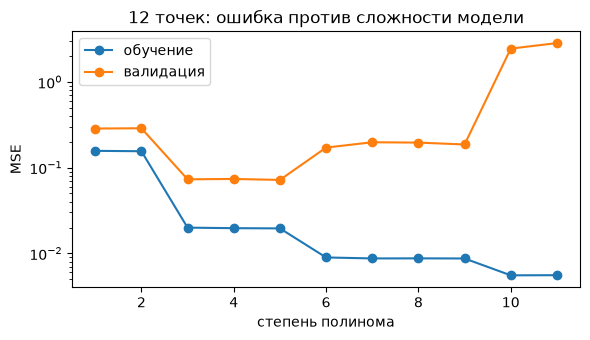

In [3]:
def make_sine(n, seed):
    r = np.random.default_rng(seed)
    x = r.uniform(0, 1, n)
    return x[:, None], np.sin(2 * np.pi * x) + r.normal(0, 0.25, n)


x_tr, y_tr = make_sine(12, 1)
x_va, y_va = make_sine(500, 2)

degrees = range(1, 12)
errors = []
for d in degrees:
    m = make_pipeline(PolynomialFeatures(d), StandardScaler(), LinearRegression()).fit(x_tr, y_tr)
    errors.append((np.mean((m.predict(x_tr) - y_tr) ** 2), np.mean((m.predict(x_va) - y_va) ** 2)))
errors = np.array(errors)

fig, ax = plt.subplots(figsize=(6, 3.5))
ax.semilogy(degrees, errors[:, 0], marker="o", label="обучение")
ax.semilogy(degrees, errors[:, 1], marker="o", label="валидация")
ax.set(xlabel="степень полинома", ylabel="MSE", title="12 точек: ошибка против сложности модели")
ax.legend()
plt.tight_layout()
plt.show()

Ошибка на обучении только падает, на валидации — U-образная кривая: при степени 10–11 полином
почти проходит через все 12 точек, а между ними улетает. Зафиксируем слишком большую степень 11
и добавим L2-регуляризацию (Ridge) разной силы $\alpha$.

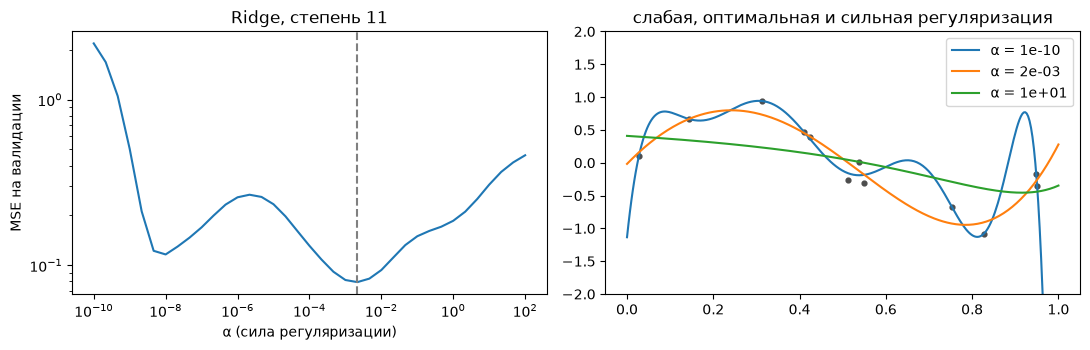

лучшее α = 2.2e-03, MSE = 0.079 (шум σ² = 0.062)


In [4]:
alphas = np.logspace(-10, 2, 37)
val_mse = []
for a in alphas:
    m = make_pipeline(PolynomialFeatures(11), StandardScaler(), Ridge(alpha=a)).fit(x_tr, y_tr)
    val_mse.append(np.mean((m.predict(x_va) - y_va) ** 2))
best = alphas[int(np.argmin(val_mse))]

grid = np.linspace(0, 1, 300)[:, None]
fig, (a1, a2) = plt.subplots(1, 2, figsize=(11, 3.6))
a1.semilogx(alphas, val_mse)
a1.axvline(best, ls="--", color="gray")
a1.set(xlabel="α (сила регуляризации)", ylabel="MSE на валидации", title="Ridge, степень 11", yscale="log")
a2.scatter(x_tr, y_tr, color="0.3", s=12)
for a in [1e-10, best, 10.0]:
    m = make_pipeline(PolynomialFeatures(11), StandardScaler(), Ridge(alpha=a)).fit(x_tr, y_tr)
    a2.plot(grid, m.predict(grid), label=f"α = {a:.0e}")
a2.set_ylim(-2, 2)
a2.legend()
a2.set_title("слабая, оптимальная и сильная регуляризация")
plt.tight_layout()
plt.show()
print(f"лучшее α = {best:.1e}, MSE = {min(val_mse):.3f} (шум σ² = {0.25 ** 2:.3f})")

Слабая регуляризация — переобучение, сильная — недообучение, в середине лучшая модель
с ошибкой, близкой к неустранимому шуму $\sigma^2$. Кривая слева неровная: 12 точек — очень мало,
и любая оценка на них шумная. Подбирать $\alpha$ — работа кросс-валидации.

## 3. Логистическая регрессия с нуля

Возьмём числовые признаки Adult из урока 1.

In [5]:
COLUMNS = [
    "age", "workclass", "fnlwgt", "education", "education_num", "marital_status", "occupation",
    "relationship", "race", "sex", "capital_gain", "capital_loss", "hours_per_week", "native_country", "income",
]
with zipfile.ZipFile(fetch("adult") / "adult.zip") as z:
    df = pd.concat([pd.read_csv(z.open(name), names=COLUMNS, skipinitialspace=True, na_values="?", skiprows=skip)
                    for name, skip in [("adult.data", 0), ("adult.test", 1)]], ignore_index=True)
y_all = (df["income"].str.rstrip(".") == ">50K").astype(int).to_numpy()
numeric = ["age", "education_num", "capital_gain", "capital_loss", "hours_per_week"]
X_num = df[numeric].to_numpy(float)
X_num[:, 2:4] = np.log1p(X_num[:, 2:4])  # capital_* — сильно скошенные суммы, берём логарифм

Xtr, Xte, ytr, yte = train_test_split(X_num, y_all, test_size=0.2, stratify=y_all, random_state=0)
scaler = StandardScaler().fit(Xtr)
Xtr_s, Xte_s = scaler.transform(Xtr), scaler.transform(Xte)

Модель: $p = \sigma(Xw + b)$, потери — log-loss, градиент — $\frac1n X^\top (p - y)$.

наши веса:     [ 0.5923  0.8504  0.4954  0.249   0.5101 -1.545 ]
scikit-learn:  [ 0.5923  0.8503  0.4958  0.2493  0.5098 -1.5449]
test: log-loss 0.4197 vs 0.4197, ROC-AUC 0.8229 vs 0.8229


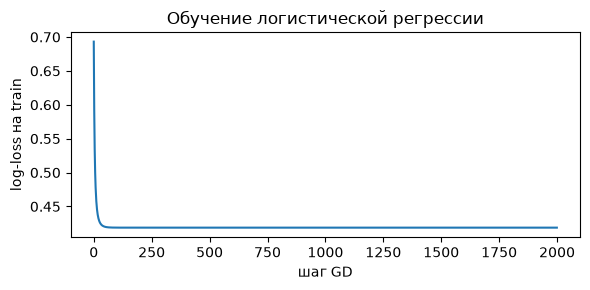

In [6]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))


def fit_logreg(X, y, lr=0.5, steps=2000):
    Xb = np.column_stack([X, np.ones(len(X))])
    w = np.zeros(Xb.shape[1])
    history = []
    for _ in range(steps):
        p = sigmoid(Xb @ w)
        w -= lr * Xb.T @ (p - y) / len(y)
        history.append(-np.mean(y * np.log(p + 1e-12) + (1 - y) * np.log(1 - p + 1e-12)))
    return w, history


w_ours, history = fit_logreg(Xtr_s, ytr)
sk_lr = LogisticRegression(C=np.inf).fit(Xtr_s, ytr)  # C = ∞ — без регуляризации, как у нас

print("наши веса:    ", w_ours)
print("scikit-learn: ", np.append(sk_lr.coef_[0], sk_lr.intercept_))
p_ours = sigmoid(np.column_stack([Xte_s, np.ones(len(Xte_s))]) @ w_ours)
print(f"test: log-loss {log_loss(yte, p_ours):.4f} vs {log_loss(yte, sk_lr.predict_proba(Xte_s)[:, 1]):.4f}, "
      f"ROC-AUC {roc_auc_score(yte, p_ours):.4f} vs {roc_auc_score(yte, sk_lr.predict_proba(Xte_s)[:, 1]):.4f}")

fig, ax = plt.subplots(figsize=(6, 3))
ax.plot(history)
ax.set(xlabel="шаг GD", ylabel="log-loss на train", title="Обучение логистической регрессии")
plt.tight_layout()
plt.show()

Двадцать строк NumPy дают тот же результат, что и scikit-learn (там вместо GD — метод L-BFGS,
он сходится за десятки итераций).

### Интерпретация весов

Признаки стандартизованы, поэтому вес — это изменение логарифма шансов при росте признака на одно
стандартное отклонение. $e^{w}$ — во сколько раз растут шансы.

In [7]:
coef = pd.DataFrame({"вес": sk_lr.coef_[0], "шансы ×": np.exp(sk_lr.coef_[0]), "σ признака": scaler.scale_},
                    index=numeric)
coef.round(3)

,вес,шансы ×,σ признака
age,0.592,1.808,13.730
education_num,0.850,2.340,2.576
capital_gain,0.496,1.642,2.450
capital_loss,0.249,1.283,1.591
hours_per_week,0.510,1.665,12.383


Образование (`education_num`) и возраст сильнее всего повышают шансы на высокий доход. Но это
связь, а не причинность: модель не знает, *почему* признаки связаны с доходом.

## 4. L1 против L2

Все признаки Adult после one-hot — больше сотни столбцов. Сравним, сколько весов оставляют ненулевыми
L1 и L2 при разной силе регуляризации $C = 1/\lambda$ (меньше $C$ — сильнее регуляризация).

In [8]:
X_df = df.drop(columns=["income", "fnlwgt"]).fillna("unknown")
categorical = [c for c in X_df.columns if c not in numeric]
Xtr_df, Xva_df, ytr2, yva2 = train_test_split(X_df, y_all, test_size=0.2, stratify=y_all, random_state=0)
prep = ColumnTransformer([("num", StandardScaler(), numeric),
                          ("cat", OneHotEncoder(handle_unknown="ignore"), categorical)]).fit(Xtr_df)
A, B = prep.transform(Xtr_df), prep.transform(Xva_df)
names = prep.get_feature_names_out()
print("признаков после one-hot:", A.shape[1])

rows = []
for C in [0.001, 0.003, 0.01, 0.03, 0.1, 1.0]:
    for kind, l1_ratio in [("L2", 0.0), ("L1", 1.0)]:
        m = LogisticRegression(C=C, l1_ratio=l1_ratio, solver="saga", max_iter=3000).fit(A, ytr2)
        rows.append({"C": C, "регуляризация": kind, "ненулевых весов": int(np.sum(np.abs(m.coef_) > 1e-6)),
                     "ROC-AUC": roc_auc_score(yva2, m.predict_proba(B)[:, 1])})
table = pd.DataFrame(rows).pivot(index="C", columns="регуляризация")
table.round(3)

признаков после one-hot: 107


ненулевых весов      ROC-AUC       
регуляризация              L1   L2      L1     L2
C                                                
0.001                       6  107   0.885  0.896
0.003                       7  107   0.895  0.902
0.010                      17  107   0.902  0.907
0.030                      29  107   0.907  0.908
0.100                      43  107   0.909  0.909
1.000                      87  107   0.909  0.909

L2 никогда не зануляет веса, только уменьшает. L1 при $C = 0{,}003$ оставляет 7 признаков из 107
и теряет всего полторы сотых ROC-AUC: это встроенный отбор признаков. Какие признаки остаются?

In [9]:
m = LogisticRegression(C=0.003, l1_ratio=1.0, solver="saga", max_iter=3000).fit(A, ytr2)
kept = pd.Series(m.coef_[0], index=names)[lambda s: s.abs() > 1e-6].sort_values()
kept.round(3)

cat__occupation_Exec-managerial           0.176
num__capital_loss                         0.190
num__age                                  0.293
num__hours_per_week                       0.308
num__education_num                        0.780
num__capital_gain                         1.250
cat__marital_status_Married-civ-spouse    1.955
dtype: float64

## ✅ Итоги

- Линейная регрессия решается явно (`lstsq`) или градиентным спуском, ответ одинаковый.
- Гибкая модель без регуляризации переобучается. Силу регуляризации подбирают на валидации.
- Логистическая регрессия — сигмоида + log-loss. Её градиент устроен как у линейной регрессии.
- L2 сжимает веса, L1 зануляет часть из них и отбирает признаки.

✍️ **Упражнение:** `exercises/ex02_logreg.py` — логистическая регрессия с L2 с нуля.